CN7030 2526 (T3) Machine Learning on Big Data (OC)Second  Week Activity  By Matrika Dhamala

In [1]:
!pip install pyspark --quiet
!pip install pandas matplotlib seaborn numpy --quiet

In [4]:
import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Tutorial1_CN7030") \
                            .master("local[*]")\
                            .config("spark.some.config.option", "some-value") \
                            .getOrCreate()

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
print("✓ All libraries installed!")

✓ All libraries installed!


In [8]:
df = spark.read.csv(
    "Airline_Delay_Cause.csv",
    header=True,
    inferSchema=True
)

In [9]:
print("✓ Data loaded successfully!")
print(f"Total rows: {df.count():,}")
print(f"Total columns: {len(df.columns)}")

✓ Data loaded successfully!
Total rows: 398,233
Total columns: 21


In [10]:
print("\n" + "="*80)
print("DATA OVERVIEW")
print("="*80)
df.printSchema()
print("\nFirst 5 rows:")
df.show(5)


DATA OVERVIEW
root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- carrier: string (nullable = true)
 |-- carrier_name: string (nullable = true)
 |-- airport: string (nullable = true)
 |-- airport_name: string (nullable = true)
 |-- arr_flights: integer (nullable = true)
 |-- arr_del15: integer (nullable = true)
 |-- carrier_ct: double (nullable = true)
 |-- weather_ct: double (nullable = true)
 |-- nas_ct: double (nullable = true)
 |-- security_ct: double (nullable = true)
 |-- late_aircraft_ct: double (nullable = true)
 |-- arr_cancelled: integer (nullable = true)
 |-- arr_diverted: integer (nullable = true)
 |-- arr_delay: integer (nullable = true)
 |-- carrier_delay: integer (nullable = true)
 |-- weather_delay: integer (nullable = true)
 |-- nas_delay: integer (nullable = true)
 |-- security_delay: integer (nullable = true)
 |-- late_aircraft_delay: integer (nullable = true)


First 5 rows:
+----+-----+-------+-------------+-------+----------------

In [11]:
print("\n" + "="*80)
print("Q1: FLIGHT DELAYS OVER TIME")
print("="*80)


Q1: FLIGHT DELAYS OVER TIME


In [12]:
delay_by_time = df.groupBy("year", "month") \
    .agg(
        sum("arr_del15").alias("total_delayed"),
        sum("arr_flights").alias("total_flights"),
        (sum("arr_del15") / sum("arr_flights")).alias("delay_rate")
    ) \
    .filter(col("total_flights") > 0) \
    .sort("year", "month")

In [13]:
delay_pd = delay_by_time.toPandas()

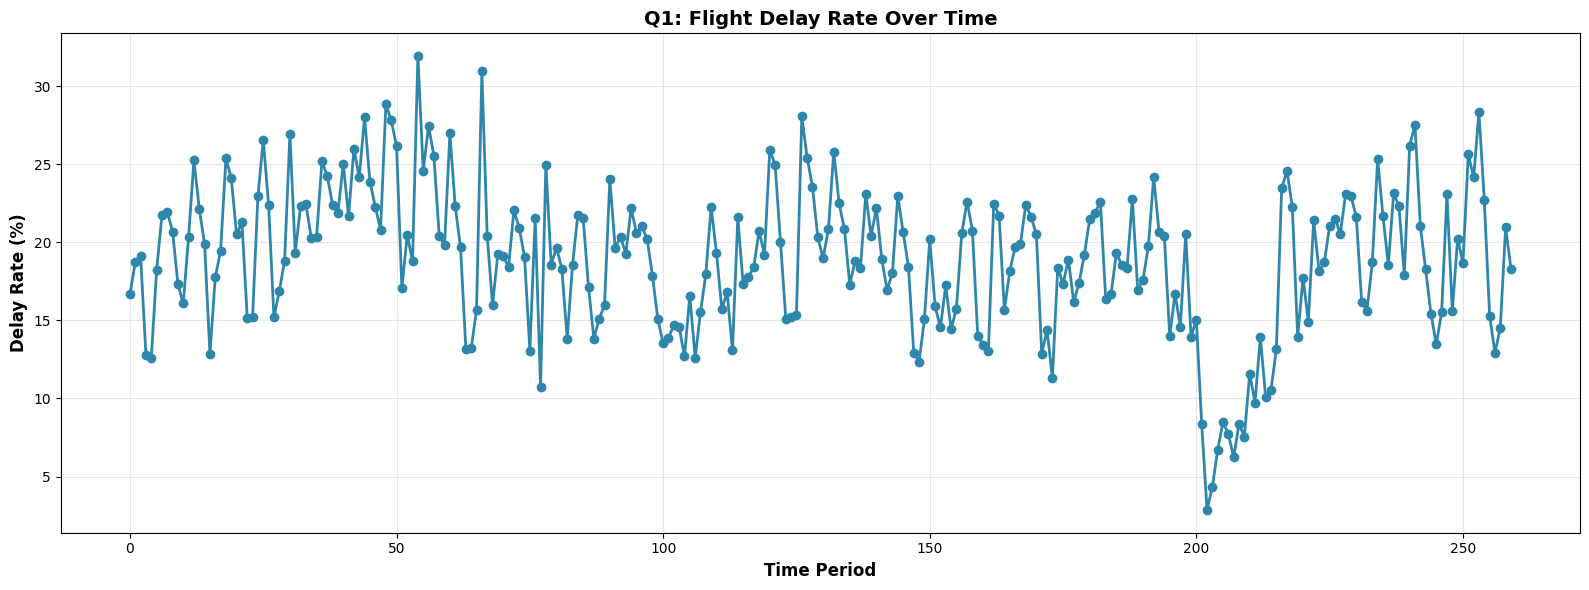

In [14]:
plt.figure(figsize=(16, 6))
plt.plot(range(len(delay_pd)), delay_pd['delay_rate']*100,
         marker='o', linewidth=2, markersize=6, color='#2E86AB')
plt.xlabel('Time Period', fontsize=12, fontweight='bold')
plt.ylabel('Delay Rate (%)', fontsize=12, fontweight='bold')
plt.title('Q1: Flight Delay Rate Over Time', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
print(f"\nHighest delay rate: {delay_pd['delay_rate'].max()*100:.2f}%")
print(f"Lowest delay rate: {delay_pd['delay_rate'].min()*100:.2f}%")
print(f"Average delay rate: {delay_pd['delay_rate'].mean()*100:.2f}%")


Highest delay rate: 31.92%
Lowest delay rate: 2.86%
Average delay rate: 18.90%


In [16]:
print("\n" + "="*80)
print("Q2: AIRLINE DELAY RATES")
print("="*80)


Q2: AIRLINE DELAY RATES


In [17]:
airline_delays = df.groupBy("carrier_name") \
    .agg(
        sum("arr_del15").alias("delayed"),
        sum("arr_flights").alias("total"),
        (sum("arr_del15") / sum("arr_flights")).alias("delay_rate")
    ) \
    .filter(col("total") > 0) \
    .sort(desc("delay_rate"))

In [18]:
airline_pd = airline_delays.toPandas()

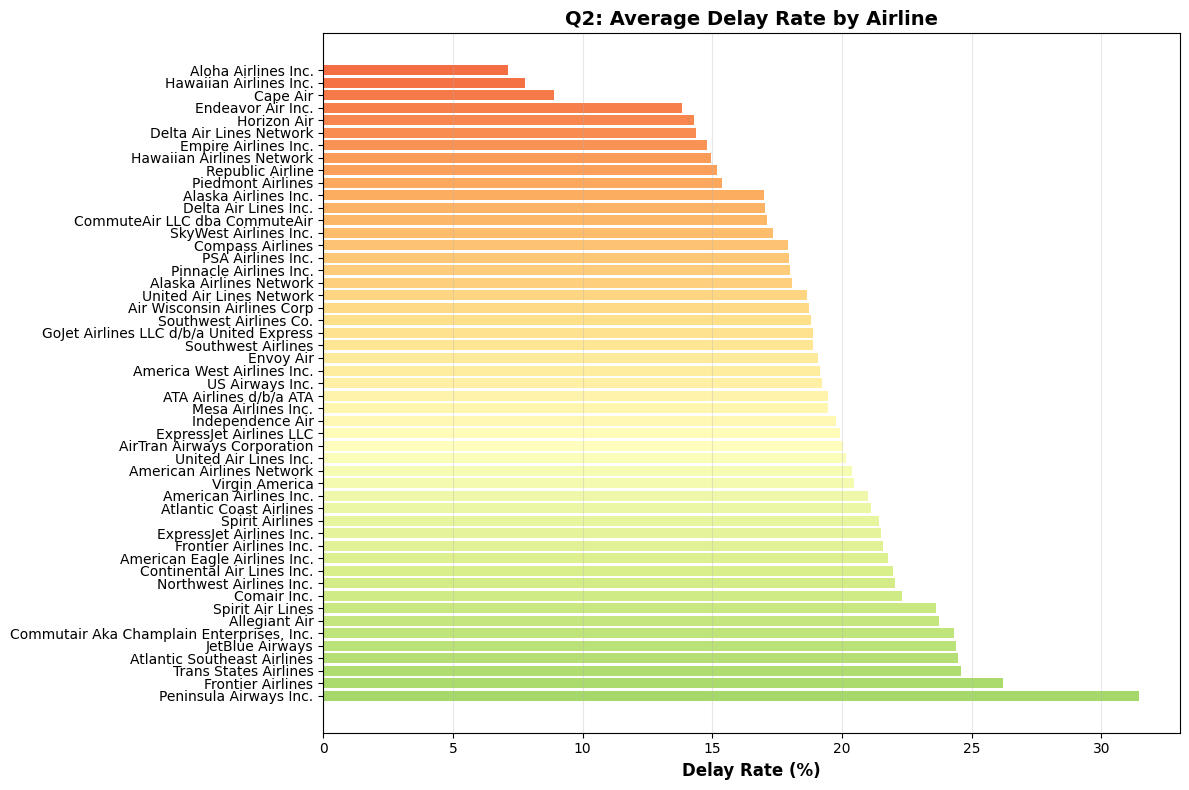

In [19]:
plt.figure(figsize=(12, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.8, len(airline_pd)))
plt.barh(airline_pd['carrier_name'], airline_pd['delay_rate']*100, color=colors)
plt.xlabel('Delay Rate (%)', fontsize=12, fontweight='bold')
plt.title('Q2: Average Delay Rate by Airline', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
print("\nAirline Rankings (worst to best):")
print(airline_pd[['carrier_name', 'delay_rate']].to_string())


Airline Rankings (worst to best):
                                 carrier_name  delay_rate
0                      Peninsula Airways Inc.    0.314534
1                           Frontier Airlines    0.262179
2                       Trans States Airlines    0.246016
3                 Atlantic Southeast Airlines    0.244661
4                             JetBlue Airways    0.243891
5   Commutair Aka Champlain Enterprises, Inc.    0.243149
6                               Allegiant Air    0.237488
7                            Spirit Air Lines    0.236331
8                                 Comair Inc.    0.223207
9                     Northwest Airlines Inc.    0.220422
10                 Continental Air Lines Inc.    0.219541
11               American Eagle Airlines Inc.    0.217798
12                     Frontier Airlines Inc.    0.215663
13                   ExpressJet Airlines Inc.    0.214883
14                            Spirit Airlines    0.214340
15                    Atlantic Coast 

In [21]:
print("\n" + "="*80)
print("Q3: CARRIER-CAUSED DELAYS")
print("="*80)


Q3: CARRIER-CAUSED DELAYS


In [94]:
carrier_delays = df.groupBy("carrier_name") \
    .agg(
        sum("carrier_ct").alias("total_carrier_delays"),
        sum("arr_flights").alias("total_flights")
    ) \
    .filter(col("total_flights") > 0) \
    .withColumn("carrier_delays_per_flight",
                col("total_carrier_delays") / col("total_flights")) \
    .sort(desc("total_carrier_delays"))

carrier_pd = carrier_delays.toPandas()



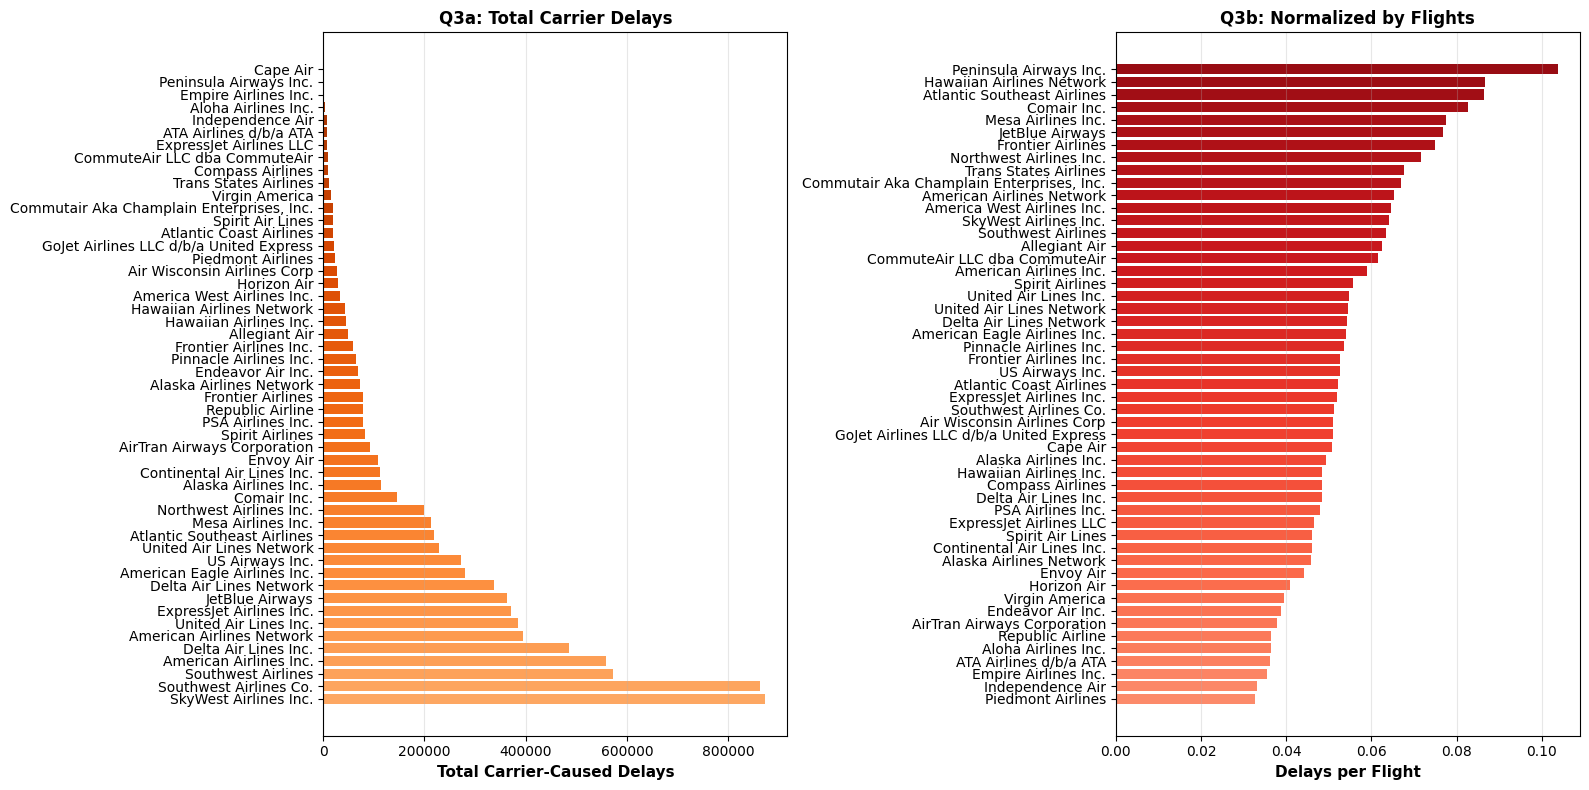

In [96]:
# Total delays
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
colors1 = plt.cm.Oranges(np.linspace(0.4, 0.9, len(carrier_pd)))
ax1.barh(carrier_pd['carrier_name'], carrier_pd['total_carrier_delays'], color=colors1)
ax1.set_xlabel('Total Carrier-Caused Delays', fontsize=11, fontweight='bold')
ax1.set_title('Q3a: Total Carrier Delays', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Normalized
carrier_sorted = carrier_pd.sort_values('carrier_delays_per_flight', ascending=True)
colors2 = plt.cm.Reds(np.linspace(0.4, 0.9, len(carrier_sorted)))
ax2.barh(carrier_sorted['carrier_name'], carrier_sorted['carrier_delays_per_flight'], color=colors2)
ax2.set_xlabel('Delays per Flight', fontsize=11, fontweight='bold')
ax2.set_title('Q3b: Normalized by Flights', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


In [97]:
print(f"\nWorst airline: {carrier_pd.iloc[0]['carrier_name']} ({carrier_pd.iloc[0]['carrier_delays_per_flight']:.2f} delays per flight)")


Worst airline: SkyWest Airlines Inc. (0.06 delays per flight)


In [65]:
print("\n" + "="*80)
print("Q4: AIRPORT DELAY RATES (TOP 25)")
print("="*80)


Q4: AIRPORT DELAY RATES (TOP 25)


In [66]:
airport_delays = df.groupBy("airport_name", "airport") \
    .agg(
        sum("arr_del15").alias("delayed"),
        sum("arr_flights").alias("total")
    ) \
    .filter(col("total") > 100) \
    .withColumn("delay_rate", col("delayed") / col("total")) \
    .sort(desc("delay_rate"))

In [67]:
airport_pd = airport_delays.toPandas().head(25)

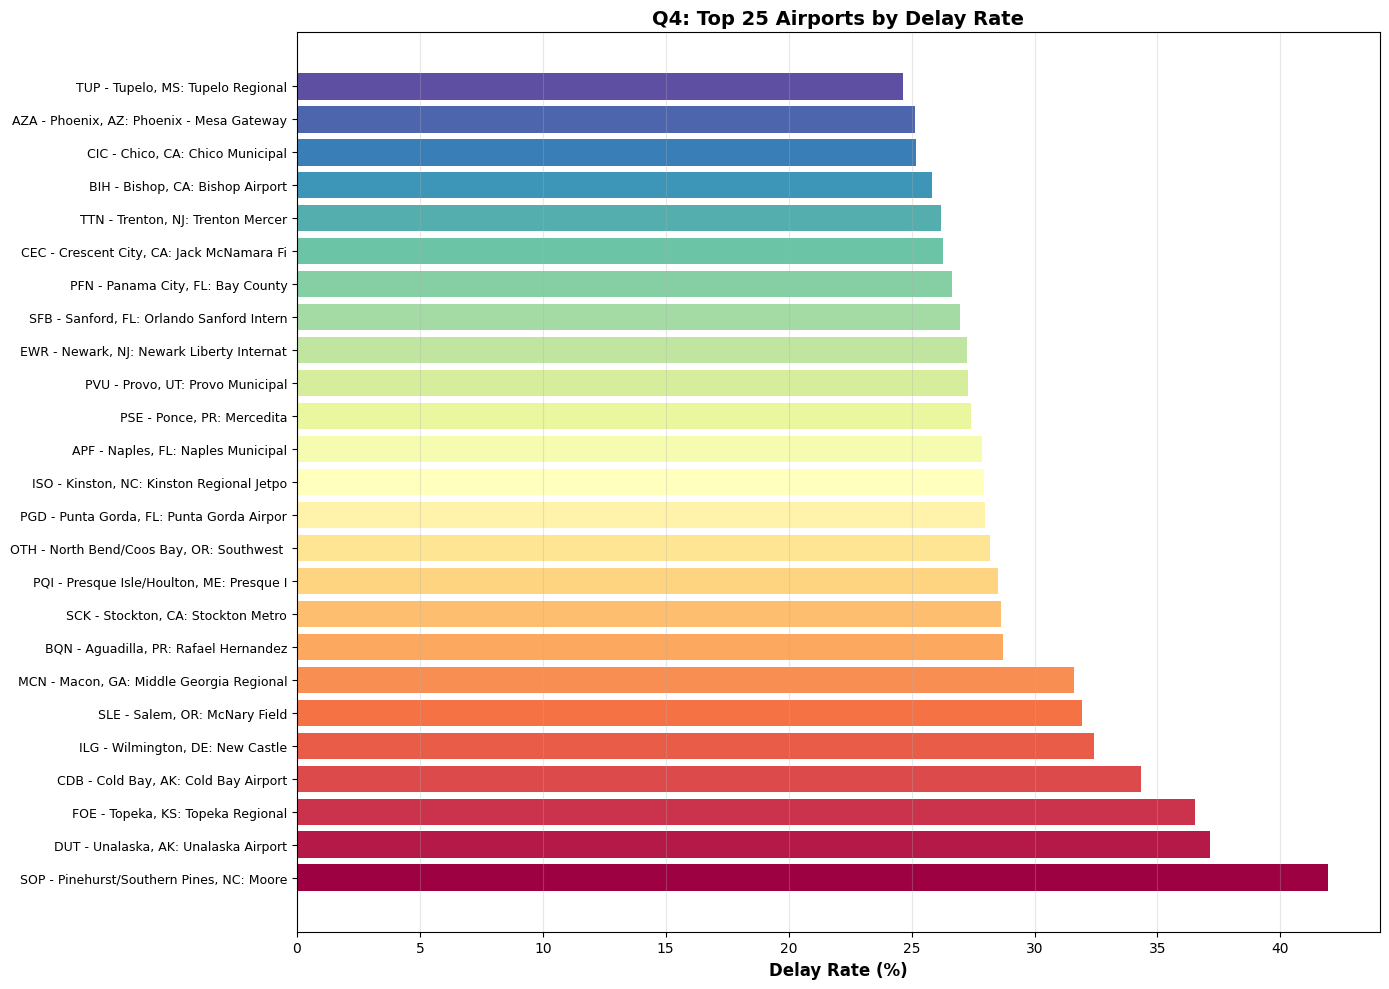

In [30]:
plt.figure(figsize=(14, 10))
colors = plt.cm.Spectral(np.linspace(0, 1, len(airport_pd)))
plt.barh(range(len(airport_pd)), airport_pd['delay_rate']*100, color=colors)
plt.yticks(range(len(airport_pd)),
           [f"{row['airport']} - {row['airport_name'][:35]}"
            for _, row in airport_pd.iterrows()], fontsize=9)
plt.xlabel('Delay Rate (%)', fontsize=12, fontweight='bold')
plt.title('Q4: Top 25 Airports by Delay Rate', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
print(f"\nWorst airport: {airport_pd.iloc[0]['airport']} ({airport_pd.iloc[0]['delay_rate']*100:.2f}%)")
print(f"Best in top 25: {airport_pd.iloc[-1]['airport']} ({airport_pd.iloc[-1]['delay_rate']*100:.2f}%)")


Worst airport: SOP (41.96%)
Best in top 25: TUP (24.65%)


In [32]:
print("\n" + "="*80)
print("Q5: DOMINANT DELAY CAUSES")
print("="*80)


Q5: DOMINANT DELAY CAUSES


In [33]:

cause_analysis = df.groupBy("year") \
    .agg(
        sum("carrier_ct").alias("carrier_delays"),
        sum("weather_ct").alias("weather_delays"),
        sum("nas_ct").alias("nas_delays"),
        sum("security_ct").alias("security_delays"),
        sum("late_aircraft_ct").alias("late_aircraft_delays")
    ) \
    .sort("year")

In [34]:
cause_pd = cause_analysis.toPandas()

In [35]:
# Calculate percentages
total_by_year = cause_pd[['carrier_delays', 'weather_delays', 'nas_delays',
                          'security_delays', 'late_aircraft_delays']].sum(axis=1)

cause_pct = cause_pd[['carrier_delays', 'weather_delays', 'nas_delays',
                       'security_delays', 'late_aircraft_delays']].div(total_by_year, axis=0) * 100

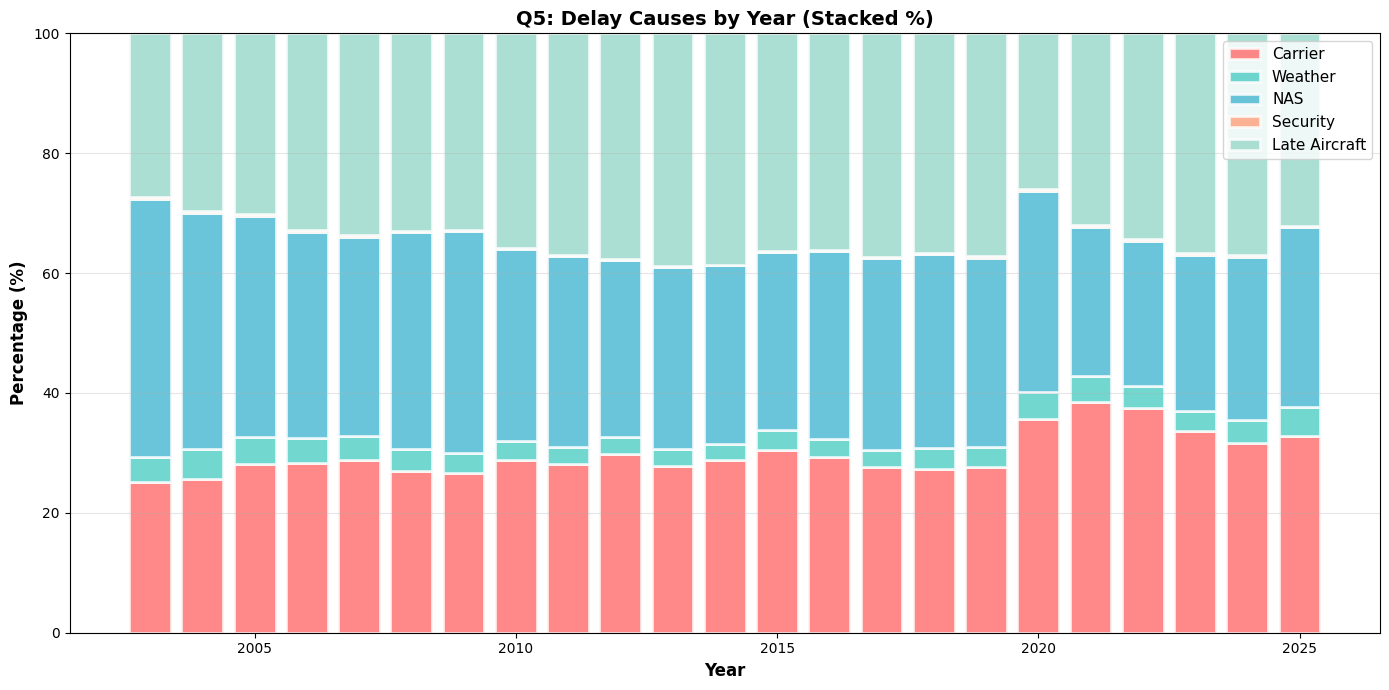

In [79]:
# Stacked bar chart
fig, ax = plt.subplots(figsize=(14, 7))

causes = ['carrier_delays', 'weather_delays', 'nas_delays', 'security_delays', 'late_aircraft_delays']
labels = ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

bottom = np.zeros(len(cause_pct))
for cause, label, color in zip(causes, labels, colors):
    ax.bar(cause_pd['year'], cause_pct[cause], label=label,
           bottom=bottom, color=color, alpha=0.8, edgecolor='white', linewidth=2)
    bottom += cause_pct[cause].values

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Q5: Delay Causes by Year (Stacked %)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [80]:
# Overall statistics
total_delays = cause_pd[causes].sum().sum()
print(f"\nTotal Delays: {total_delays:,.0f}")
print("Cause Distribution:")
for cause, label in zip(causes, labels):
    count = cause_pd[cause].sum()
    pct = (count / total_delays) * 100
    print(f"  • {label}: {count:,.0f} ({pct:.2f}%)")


Total Delays: 27,648,506
Cause Distribution:
  • Carrier: 8,166,343 (29.54%)
  • Weather: 997,212 (3.61%)
  • NAS: 8,829,976 (31.94%)
  • Security: 68,634 (0.25%)
  • Late Aircraft: 9,586,341 (34.67%)


In [41]:
print("\n" + "="*80)
print("Q6: SEASONAL VARIATION OF DELAY CAUSES")
print("="*80)


Q6: SEASONAL VARIATION OF DELAY CAUSES


In [42]:
seasonal = df.groupBy("month") \
    .agg(
        sum("carrier_ct").alias("carrier_delays"),
        sum("weather_ct").alias("weather_delays"),
        sum("nas_ct").alias("nas_delays"),
        sum("security_ct").alias("security_delays"),
        sum("late_aircraft_ct").alias("late_aircraft_delays")
    ) \
    .sort("month")

In [43]:
seasonal_pd = seasonal.toPandas()

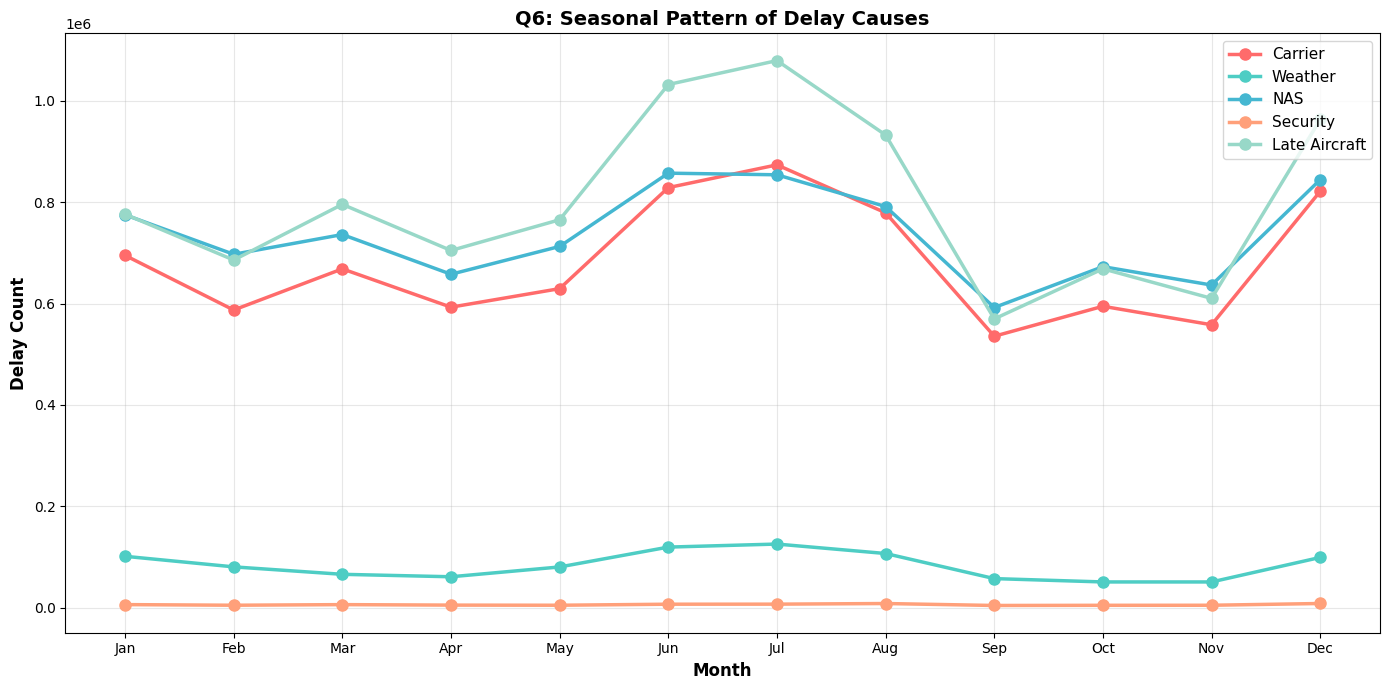

In [76]:
# Multi-line chart
fig, ax = plt.subplots(figsize=(14, 7))

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
seasonal_pd['month_name'] = seasonal_pd['month'].map(lambda x: months[int(x)-1])

causes = ['carrier_delays', 'weather_delays', 'nas_delays', 'security_delays', 'late_aircraft_delays']
labels = ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

for cause, label, color in zip(causes, labels, colors):
    ax.plot(seasonal_pd['month_name'], seasonal_pd[cause],
            marker='o', label=label, color=color, linewidth=2.5, markersize=8)

ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Delay Count', fontsize=12, fontweight='bold')
ax.set_title('Q6: Seasonal Pattern of Delay Causes', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [77]:
print("\nSeasonal peaks:")
print(f"  • Weather delays peak in month: {seasonal_pd.loc[seasonal_pd['weather_delays'].idxmax(), 'month']}")
print(f"  • Late aircraft delays peak in month: {seasonal_pd.loc[seasonal_pd['late_aircraft_delays'].idxmax(), 'month']}")
print(f"  • Carrier delays peak in month: {seasonal_pd.loc[seasonal_pd['carrier_delays'].idxmax(), 'month']}")


Seasonal peaks:
  • Weather delays peak in month: 7
  • Late aircraft delays peak in month: 7
  • Carrier delays peak in month: 7


In [78]:
print("\n" + "="*80)
print("Q7: MONTHLY SEASONALITY IN DELAY PERCENTAGES")
print("="*80)


Q7: MONTHLY SEASONALITY IN DELAY PERCENTAGES


In [88]:
monthly = df.groupBy("month") \
    .agg(
        sum("arr_del15").alias("delayed"),
        sum("arr_flights").alias("total")
    ) \
    .filter(col("total") > 0) \
    .withColumn("delay_rate", (col("delayed") / col("total")) * 100) \
    .sort("month")

monthly_pd = monthly.toPandas()
monthly_pd['month_name'] = monthly_pd['month'].map(lambda x: months[int(x)-1])



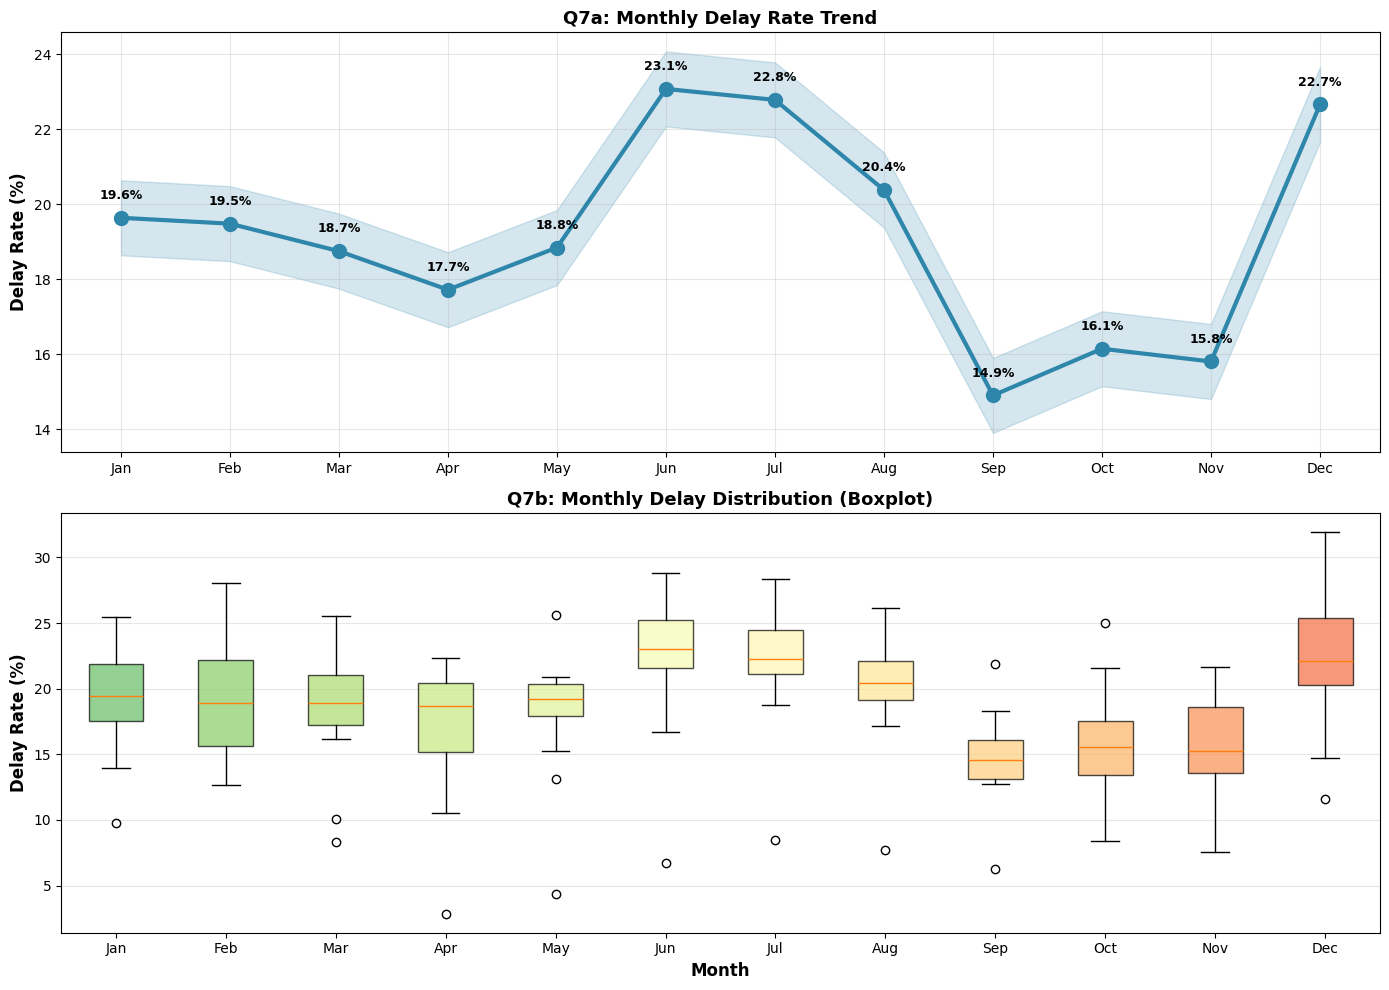

In [92]:
# Top: Line chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
ax1.plot(monthly_pd['month_name'], monthly_pd['delay_rate'],
         marker='o', color='#2E86AB', linewidth=3, markersize=10)
ax1.fill_between(range(len(monthly_pd)), monthly_pd['delay_rate']-1,
                 monthly_pd['delay_rate']+1, alpha=0.2, color='#2E86AB')
ax1.set_ylabel('Delay Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Q7a: Monthly Delay Rate Trend', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
for i, v in enumerate(monthly_pd['delay_rate']):
    ax1.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

monthly_year = df.groupBy("year", "month") \
    .agg((sum("arr_del15") / sum("arr_flights")).alias("delay_rate")) \
    .filter(col("delay_rate").isNotNull()) \
    .toPandas()

delay_data = [monthly_year[monthly_year['month'] == i+1]['delay_rate'].values * 100
              for i in range(12)]

bp = ax2.boxplot(delay_data, labels=months, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 12))):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_xlabel('Month', fontsize=12, fontweight='bold')
ax2.set_ylabel('Delay Rate (%)', fontsize=12, fontweight='bold')
ax2.set_title('Q7b: Monthly Delay Distribution (Boxplot)', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [93]:
print("\nMonthly Seasonality Summary:")
print(f"  • Highest delay month: {monthly_pd.loc[monthly_pd['delay_rate'].idxmax(), 'month_name']} ({monthly_pd['delay_rate'].max():.2f}%)")
print(f"  • Lowest delay month: {monthly_pd.loc[monthly_pd['delay_rate'].idxmin(), 'month_name']} ({monthly_pd['delay_rate'].min():.2f}%)")
print(f"  • Seasonality range: {monthly_pd['delay_rate'].max() - monthly_pd['delay_rate'].min():.2f}%")


Monthly Seasonality Summary:
  • Highest delay month: Jun (23.07%)
  • Lowest delay month: Sep (14.90%)
  • Seasonality range: 8.17%


In [53]:
print("\n" + "="*80)
print("COMPREHENSIVE ANALYSIS COMPLETE ✓")
print("="*80)



COMPREHENSIVE ANALYSIS COMPLETE ✓


In [54]:

print(f"\n📊 DATASET SUMMARY:")
print(f"  • Total flights: {df.select(sum('arr_flights')).collect()[0][0]:,.0f}")
print(f"  • Delayed flights (15+ min): {df.select(sum('arr_del15')).collect()[0][0]:,.0f}")
print(f"  • Overall delay rate: {(df.select(sum('arr_del15')).collect()[0][0] / df.select(sum('arr_flights')).collect()[0][0] * 100):.2f}%")
print(f"  • Airlines: {df.select('carrier_name').distinct().count()}")
print(f"  • Airports: {df.select('airport').distinct().count()}")


📊 DATASET SUMMARY:
  • Total flights: 143,788,742
  • Delayed flights (15+ min): 27,648,492
  • Overall delay rate: 19.23%
  • Airlines: 51
  • Airports: 425


In [55]:
print(f"\n🎯 KEY FINDINGS:")
print(f"  ✓ Q1: Delay trends analyzed by time period")
print(f"  ✓ Q2: Airline performance ranked")
print(f"  ✓ Q3: Carrier-caused delays identified")
print(f"  ✓ Q4: Airport delay rates computed")
print(f"  ✓ Q5: Dominant delay causes determined")
print(f"  ✓ Q6: Seasonal patterns revealed")
print(f"  ✓ Q7: Monthly seasonality quantified")


🎯 KEY FINDINGS:
  ✓ Q1: Delay trends analyzed by time period
  ✓ Q2: Airline performance ranked
  ✓ Q3: Carrier-caused delays identified
  ✓ Q4: Airport delay rates computed
  ✓ Q5: Dominant delay causes determined
  ✓ Q6: Seasonal patterns revealed
  ✓ Q7: Monthly seasonality quantified


In [56]:
print("\n" + "="*80)
print("✅ All analysis complete! Check visualizations above.")
print("="*80)


✅ All analysis complete! Check visualizations above.
